# Black-Scholes Model & the Greeks

Implement BS option pricing from scratch, verify put-call parity, visualise all five Greeks, and build a Newton-Raphson implied volatility solver.

**Theory references:** [Black-Scholes](../theory/02_options/black_scholes.md) | [Derivatives & Hedging](../theory/02_options/derivatives_and_hedging.md) | [Greeks](../theory/02_options/greeks.md) | [Implied Volatility](../theory/02_options/implied_volatility.md)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'axes.titleweight': 'normal',
    'legend.fontsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
COLORS = ['#534AB7', '#0F6E56', '#D85A30', '#185FA5', '#993556', '#3B6D11', '#BA7517']

import os


def save_fig(fig, topic: str, name: str) -> None:
    folder = os.path.join('..', 'plots', topic)
    os.makedirs(folder, exist_ok=True)
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(folder, f'{name}.{ext}'))

from scipy.stats import norm


## Section 1 — Black-Scholes Pricing

A delta-hedged portfolio removes diffusion risk and yields the Black–Scholes PDE, and the closed-form $C$ and $P$ with $d_1,d_2$ satisfy put–call parity $C-P=S-Ke^{-rT}$ as coded below. Background is in [black_scholes.md](../theory/02_options/black_scholes.md) and [derivatives_and_hedging.md](../theory/02_options/derivatives_and_hedging.md).


In [2]:
def bs_d1(S: np.ndarray | float, K: float, T: float, r: float, sigma: float) -> np.ndarray | float:
    """Compute d1 in the Black-Scholes formula."""
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))


def bs_d2(S: np.ndarray | float, K: float, T: float, r: float, sigma: float) -> np.ndarray | float:
    """Compute d2 = d1 - sigma * sqrt(T)."""
    return bs_d1(S, K, T, r, sigma) - sigma * np.sqrt(T)


def bs_call(S: np.ndarray | float, K: float, T: float, r: float, sigma: float) -> np.ndarray | float:
    """Black-Scholes European call option price."""
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def bs_put(S: np.ndarray | float, K: float, T: float, r: float, sigma: float) -> np.ndarray | float:
    """Black-Scholes European put option price."""
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


In [3]:
K, r, sigma = 100.0, 0.05, 0.2
S_vals = np.array([80.0, 90.0, 100.0, 110.0, 120.0])
T_vals = np.array([0.25, 0.5, 1.0])
max_dev = 0.0
print(f"{'S':>6} {'T':>6} {'C':>10} {'P':>10} {'C-P':>10} {'S-Ke^-rT':>10} {'Error':>12}")
print('-' * 70)
for S in S_vals:
    for T in T_vals:
        c = bs_call(S, K, T, r, sigma)
        p = bs_put(S, K, T, r, sigma)
        lhs = c - p
        rhs = S - K * np.exp(-r * T)
        err = abs(lhs - rhs)
        max_dev = max(max_dev, err)
        print(f"{S:6.0f} {T:6.2f} {c:10.4f} {p:10.4f} {lhs:10.4f} {rhs:10.4f} {err:12.2e}")
print(f"\nMax put-call parity deviation: {max_dev:.2e}")


     S      T          C          P        C-P   S-Ke^-rT        Error
----------------------------------------------------------------------
    80   0.25     0.0564    18.8142   -18.7578   -18.7578     1.07e-14
    80   0.50     0.4562    17.9871   -17.5310   -17.5310     3.55e-15
    80   1.00     1.8594    16.9824   -15.1229   -15.1229     3.55e-15
    90   0.25     0.8975     9.6553    -8.7578    -8.7578     7.11e-15
    90   0.50     2.3494     9.8804    -7.5310    -7.5310     3.55e-15
    90   1.00     5.0912    10.2142    -5.1229    -5.1229     0.00e+00
   100   0.25     4.6150     3.3728     1.2422     1.2422     7.11e-15
   100   0.50     6.8887     4.4197     2.4690     2.4690     7.11e-15
   100   1.00    10.4506     5.5735     4.8771     4.8771     0.00e+00
   110   0.25    11.9883     0.7461    11.2422    11.2422     5.33e-15
   110   0.50    14.0754     1.6064    12.4690    12.4690     1.07e-14
   110   1.00    17.6630     2.7859    14.8771    14.8771     3.55e-15
   120

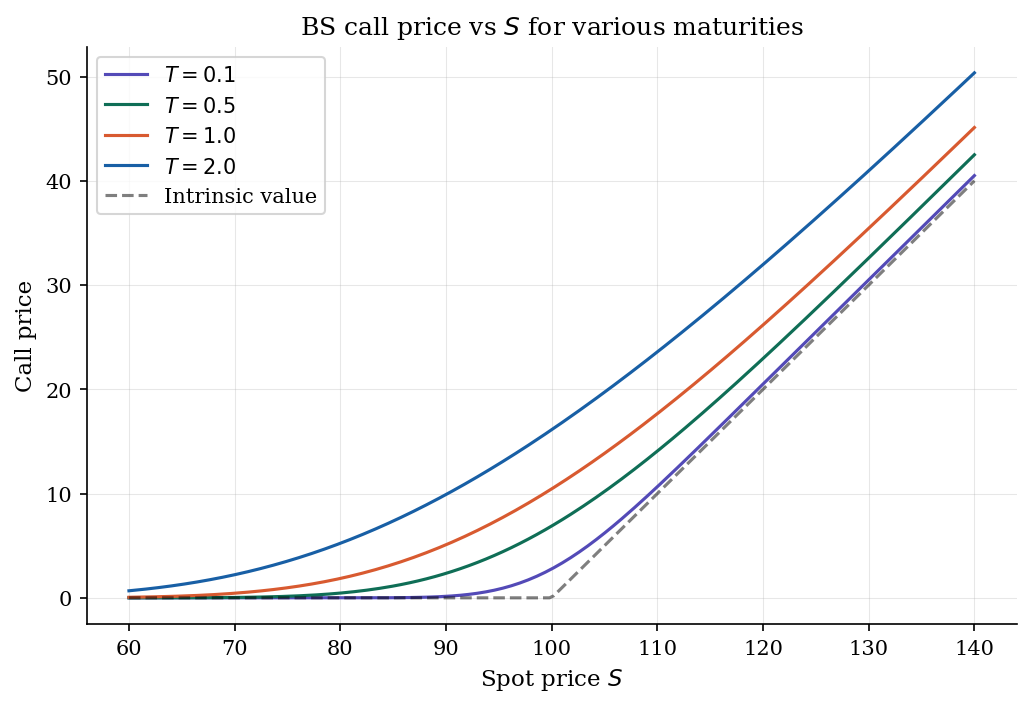

In [4]:
S_range = np.linspace(60, 140, 200)
K, r, sigma = 100.0, 0.05, 0.2
T_list = [0.1, 0.5, 1.0, 2.0]
fig, ax = plt.subplots(figsize=(8, 5))
for i, T in enumerate(T_list):
    ax.plot(S_range, bs_call(S_range, K, T, r, sigma), color=COLORS[i], label=f'$T = {T}$')
ax.plot(S_range, np.maximum(S_range - K, 0), 'k--', alpha=0.5, label='Intrinsic value')
ax.set_xlabel(r'Spot price $S$')
ax.set_ylabel('Call price')
ax.set_title(r'BS call price vs $S$ for various maturities')
ax.legend()
save_fig(fig, '02_options', 'bs_call_price_vs_S')
plt.show()


## Section 2 — The Greeks

The plots summarise $\Delta$, $\Gamma$, $\mathcal{V}$, $\Theta$, and $\rho$ and how convexity trades off against theta decay for a long option position. Formulas and interpretation are in [greeks.md](../theory/02_options/greeks.md).


In [5]:
def bs_delta_call(S, K, T, r, sigma):
    """Delta of a European call: N(d1)."""
    return norm.cdf(bs_d1(S, K, T, r, sigma))


def bs_delta_put(S, K, T, r, sigma):
    """Delta of a European put: N(d1) - 1."""
    return norm.cdf(bs_d1(S, K, T, r, sigma)) - 1.0


def bs_gamma(S, K, T, r, sigma):
    """Gamma (same for calls and puts)."""
    d1 = bs_d1(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))


def bs_vega(S, K, T, r, sigma):
    """Vega (same for calls and puts)."""
    d1 = bs_d1(S, K, T, r, sigma)
    return S * norm.pdf(d1) * np.sqrt(T)


def bs_theta_call(S, K, T, r, sigma):
    """Theta of a European call (per year)."""
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    return -S * norm.pdf(d1) * sigma / (2.0 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)


def bs_theta_put(S, K, T, r, sigma):
    """Theta of a European put (per year)."""
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    return -S * norm.pdf(d1) * sigma / (2.0 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)


def bs_rho_call(S, K, T, r, sigma):
    """Rho of a European call."""
    d2 = bs_d2(S, K, T, r, sigma)
    return K * T * np.exp(-r * T) * norm.cdf(d2)


def bs_rho_put(S, K, T, r, sigma):
    """Rho of a European put."""
    d2 = bs_d2(S, K, T, r, sigma)
    return -K * T * np.exp(-r * T) * norm.cdf(-d2)


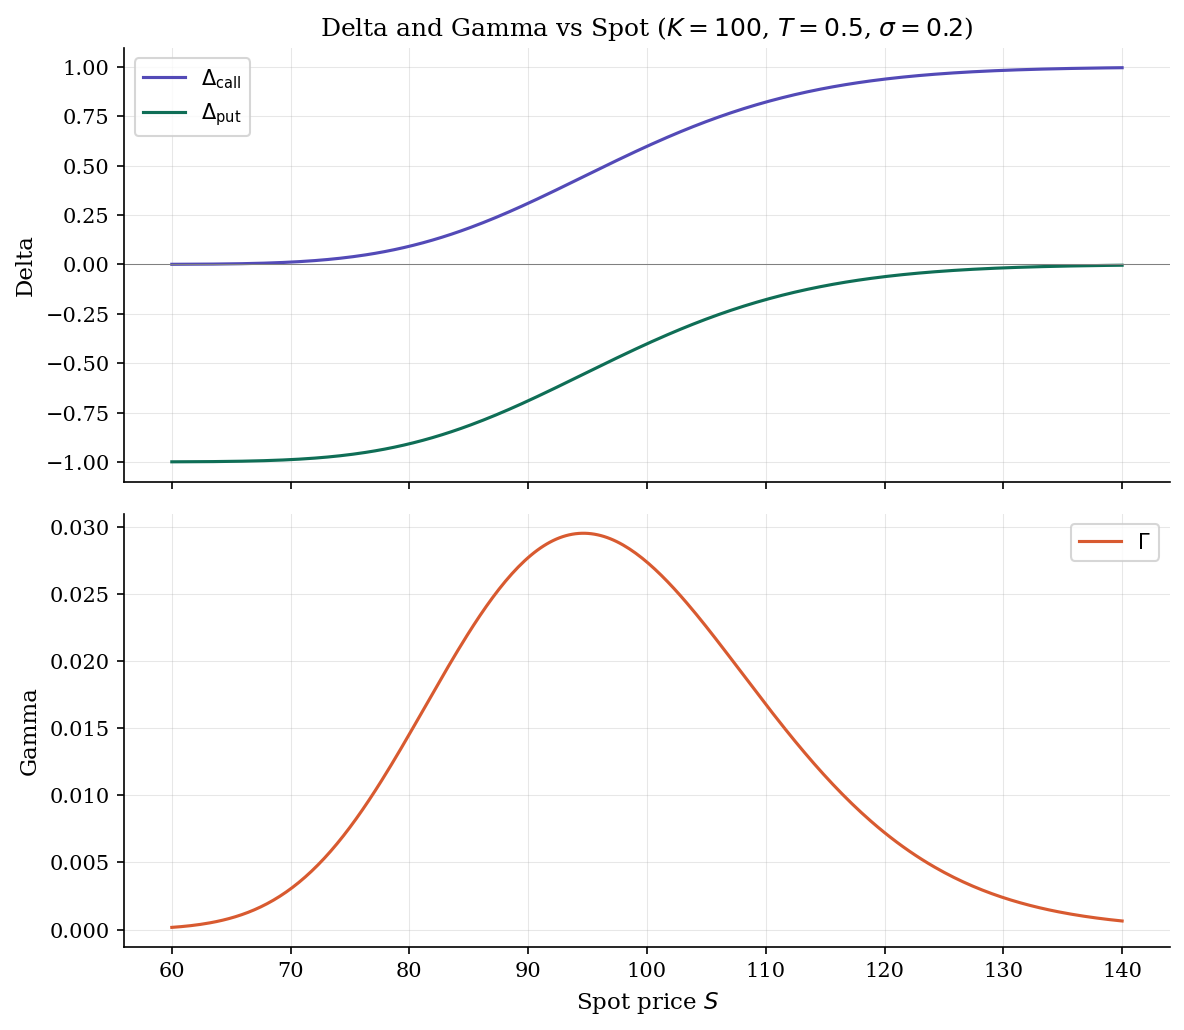

In [6]:
S_range = np.linspace(60, 140, 300)
K, T, r, sigma = 100.0, 0.5, 0.05, 0.2
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
ax1.plot(S_range, bs_delta_call(S_range, K, T, r, sigma), color=COLORS[0], label=r'$\Delta_{\mathrm{call}}$')
ax1.plot(S_range, bs_delta_put(S_range, K, T, r, sigma), color=COLORS[1], label=r'$\Delta_{\mathrm{put}}$')
ax1.axhline(0, color='gray', lw=0.5)
ax1.set_ylabel('Delta')
ax1.set_title(r'Delta and Gamma vs Spot ($K=100$, $T=0.5$, $\sigma=0.2$)')
ax1.legend()
ax2.plot(S_range, bs_gamma(S_range, K, T, r, sigma), color=COLORS[2], label=r'$\Gamma$')
ax2.set_xlabel(r'Spot price $S$')
ax2.set_ylabel('Gamma')
ax2.legend()
fig.tight_layout()
save_fig(fig, '02_options', 'delta_gamma_vs_S')
plt.show()


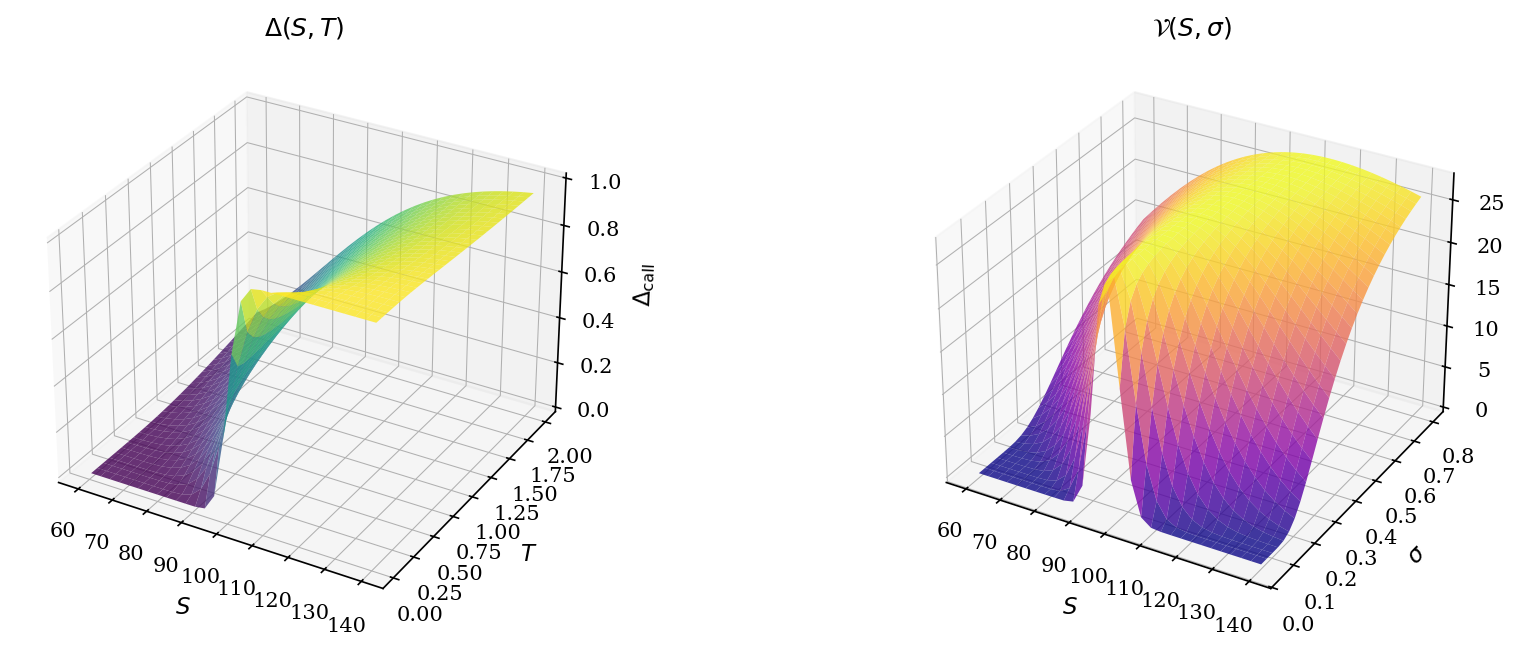

In [7]:
from matplotlib.animation import FuncAnimation, PillowWriter

# Grids & Surfaces
S_grid = np.linspace(60, 140, 30)
T_grid = np.linspace(0.02, 2.0, 30)
sigma_grid = np.linspace(0.05, 0.8, 30)
K, r = 100.0, 0.05

S_mesh_T, T_mesh = np.meshgrid(S_grid, T_grid)
delta_surface = np.zeros_like(S_mesh_T)
for i in range(len(T_grid)):
    delta_surface[i, :] = bs_delta_call(S_grid, K, T_grid[i], r, 0.2)

S_mesh_s, sig_mesh = np.meshgrid(S_grid, sigma_grid)
vega_surface = np.zeros_like(S_mesh_s)
for i in range(len(sigma_grid)):
    vega_surface[i, :] = bs_vega(S_grid, K, 0.5, r, sigma_grid[i])

# Plot
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

ax1.plot_surface(S_mesh_T, T_mesh, delta_surface, cmap='viridis', alpha=0.8)
ax1.set_xlabel(r'$S$'); ax1.set_ylabel(r'$T$'); ax1.set_zlabel(r'$\Delta_{\mathrm{call}}$')
ax1.set_title(r'$\Delta(S, T)$')

ax2.plot_surface(S_mesh_s, sig_mesh, vega_surface, cmap='plasma', alpha=0.8)
ax2.set_xlabel(r'$S$'); ax2.set_ylabel(r'$\sigma$'); ax2.set_zlabel(r'$\mathcal{V}$')
ax2.set_title(r'$\mathcal{V}(S, \sigma)$')

plt.show()
save_fig(fig, '02_options', 'greeks_3d_surfaces')

def animate(frame):
    ax1.view_init(elev=25, azim=frame)
    ax2.view_init(elev=25, azim=frame)
    return []

ani = FuncAnimation(fig, animate, frames=range(0, 360, 2), interval=50, blit=False)
# ani.save('../plots/02_options/greeks_3d_rotating.gif', writer=PillowWriter(fps=20))

## Section 3 — Implied Volatility

Implied volatility solves $C_{\mathrm{BS}}(\sigma)=C_{\mathrm{mkt}}$ by Newton–Raphson with Vega in the denominator, and systematic variation of $\sigma_{\mathrm{impl}}$ with strike or maturity is the smile or skew. Read [implied_volatility.md](../theory/02_options/implied_volatility.md).


In [8]:
def implied_vol(price: float, S: float, K: float, T: float, r: float,
                is_call: bool = True, tol: float = 1e-8, max_iter: int = 100) -> float:
    """Implied volatility via Newton-Raphson with Vega as Jacobian."""
    sigma = 0.2
    for _ in range(max_iter):
        model_price = bs_call(S, K, T, r, sigma) if is_call else bs_put(S, K, T, r, sigma)
        diff = model_price - price
        if abs(diff) < tol:
            break
        v = bs_vega(S, K, T, r, sigma)
        if v < 1e-12:
            break
        sigma -= diff / v
        sigma = max(sigma, 1e-6)
    return float(sigma)


test_sigma = 0.30
test_price = bs_call(100.0, 100.0, 1.0, 0.05, test_sigma)
recovered = implied_vol(test_price, 100.0, 100.0, 1.0, 0.05)
print(f'True sigma: {test_sigma:.4f}')
print(f'Recovered:  {recovered:.4f}')
print(f'Error:      {abs(recovered - test_sigma):.2e}')


True sigma: 0.3000
Recovered:  0.3000
Error:      3.33e-16


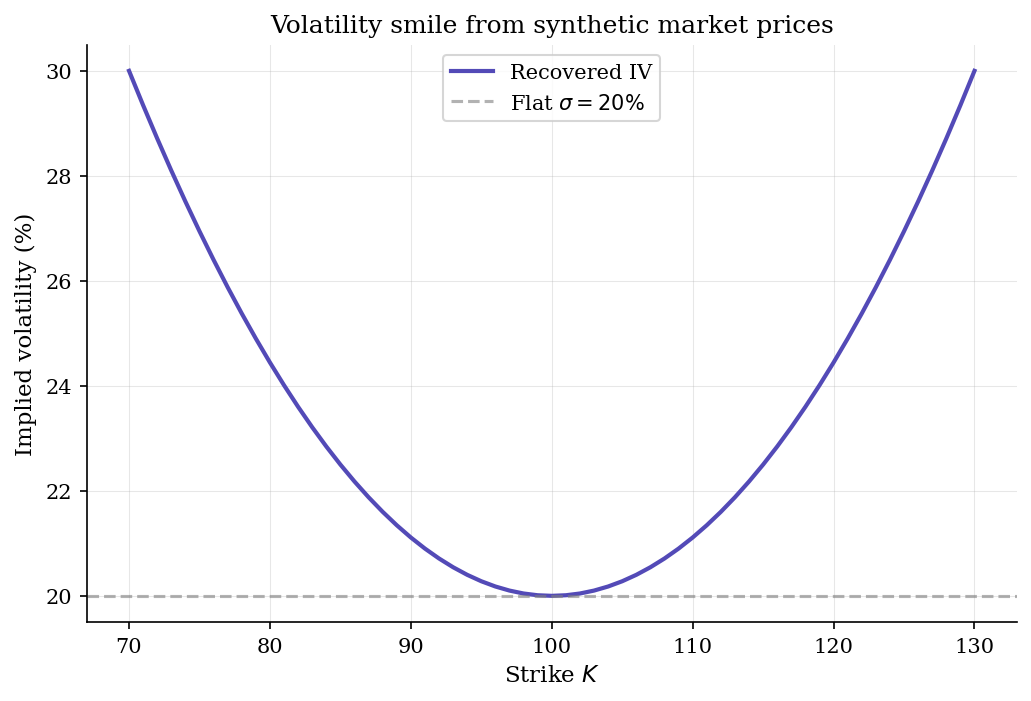

In [9]:
K_range = np.arange(70, 131, dtype=float)
S, T, r = 100.0, 0.5, 0.05
sigma_true = 0.2 + 0.1 * ((K_range - 100) / 30)**2
market_prices = np.array([bs_call(S, k, T, r, s) for k, s in zip(K_range, sigma_true)])
recovered_ivs = np.array([implied_vol(p, S, k, T, r) for p, k in zip(market_prices, K_range)])
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, recovered_ivs * 100, color=COLORS[0], lw=2, label='Recovered IV')
ax.axhline(20.0, color='gray', ls='--', alpha=0.6, label=r'Flat $\sigma = 20\%$')
ax.set_xlabel('Strike $K$')
ax.set_ylabel('Implied volatility (%)')
ax.set_title('Volatility smile from synthetic market prices')
ax.legend()
save_fig(fig, '02_options', 'vol_smile')
plt.show()


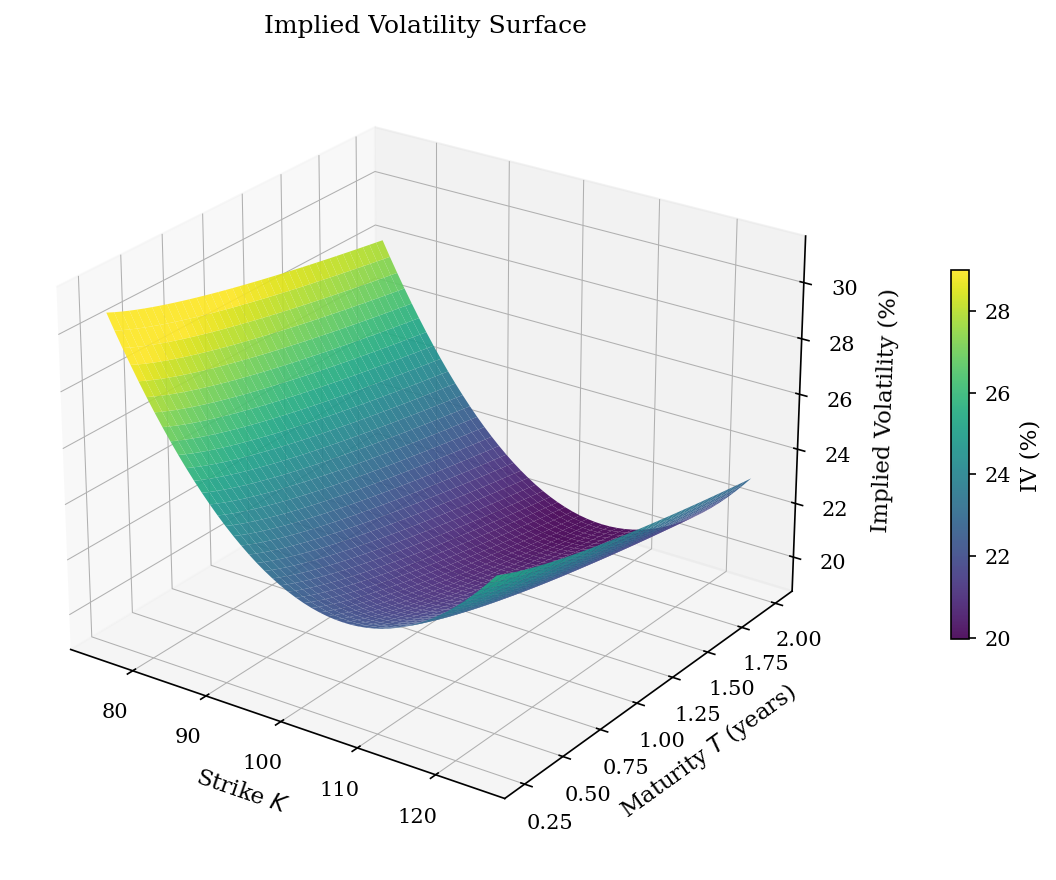

In [10]:
K_surf = np.linspace(75, 125, 50)  # Ränder wegschneiden
T_surf = np.linspace(0.25, 2.0, 40)  # Sehr kurze Laufzeiten weglassen
K_mesh, T_mesh = np.meshgrid(K_surf, T_surf)
S_surf, r_surf = 100.0, 0.05
sigma_input = (
    0.20
    + 0.08 * ((K_mesh - S_surf) / 30) ** 2
    - 0.03 * (K_mesh - S_surf) / 30
    + 0.04 * (1 - np.sqrt(T_mesh) / np.sqrt(2.0))
)
market_prices_surf = np.vectorize(
    lambda k, t, s: bs_call(S_surf, k, t, r_surf, s)
)(K_mesh, T_mesh, sigma_input)
iv_surf = np.vectorize(
    lambda p, k, t: implied_vol(p, S_surf, k, t, r_surf)
)(market_prices_surf, K_mesh, T_mesh)

# --- Fix: Ausreisser maskieren ---
iv_pct = iv_surf * 100
iv_pct = np.where(np.isfinite(iv_pct), iv_pct, np.nan)
iv_pct = np.clip(iv_pct, 5, 60)  
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

surf_plot = ax.plot_surface(
    K_mesh, T_mesh, iv_pct,
    cmap='viridis',
    alpha=0.92,
    vmin=np.nanpercentile(iv_pct, 2),
    vmax=np.nanpercentile(iv_pct, 98),
)
fig.colorbar(surf_plot, ax=ax, shrink=0.45, pad=0.08, label='IV (%)')
ax.set_xlabel('Strike $K$')
ax.set_ylabel('Maturity $T$ (years)')
ax.set_zlabel('Implied Volatility (%)')
ax.set_title('Implied Volatility Surface')
ax.set_zlim(np.nanmin(iv_pct) - 1, np.nanmax(iv_pct) + 1)
ax.view_init(elev=25, azim=-55)
plt.tight_layout()

plt.show()
save_fig(fig, '02_options', 'vol_surface')

def animate(frame):
    ax.view_init(elev=25, azim=frame)
    return []

ani = FuncAnimation(fig, animate, frames=range(0, 360, 2), interval=50, blit=False)
# ani.save('../plots/02_options/vol_surface_rotating.gif', writer=PillowWriter(fps=20))
  

## Prosperity 4 Takeaways

Black–Scholes remains a fast fair-value benchmark: hedge $\Delta$ while monitoring $\Gamma$ and $\Theta$, and calibrate $\sigma$ where Vega is large. A stable smile is a flag for model risk or jump premia when you quote option-like payoffs.
